# Lab 1: getting to know your dataset

Welcome to your first hands-on session with the ACS dataset. You will keep working with this same dataset for the next 6 weeks, so today is about **getting a feel for it**: what it contains, what it looks like, and what might be off.

**Goals of this lab**

1. Load the dataset and inspect its structure.
2. Apply the univariate tools seen in class.
3. Reproduce a few figures from the lecture.
4. Spot anomalies 

**Reminders**

- Fixed seed: `random_state=42`.
- Run *Restart & Run All* before you leave.
- No deliverable to submit today. But keep this notebook: you will build on it next session.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="white", context="notebook")

SEED = 42

## Part 1: First look

Load the dataset and inspect its structure. The file is provided in the `data/` folder.

In [2]:
df = pd.read_csv("data/acs_ca_2018_fil_rouge.csv")

In [3]:
# TODO: inspect the shape, the first rows, and the dtypes.
# Hint: df.shape, df.head(), df.dtypes
print(df.shape)
print(df.head())
print(df.dtypes)



(195744, 11)
   age  education marital_status         worker_class  occupation_code  \
0   54       18.0  Never married  Private, non-profit             4720   
1   64       21.0        Married  Private, for-profit              140   
2   38       19.0        Married  Private, for-profit             7000   
3   30        NaN        Married  Private, for-profit             3300   
4   46       19.0  Never married  Private, for-profit             4020   

   hours_per_week     sex  race   income  state  income_estimate_from_peers  
0            39.0  Female     8   8000.0      6                     12105.0  
1            40.0    Male     1  82000.0      6                     86261.0  
2            38.0  Female     1  59000.0      6                     60754.0  
3            40.0  Female     1  40000.0      6                     45039.0  
4            30.0    Male     6  23000.0      6                     25869.0  
age                             int64
education                     float6

**Question 1.** How many rows? How many columns? What does one row represent here?

il y a 195744 ligne et chaque ligne represente une persone en fait 

In [4]:
# TODO: run df.describe(). What does it show? What does it NOT show?
df.describe()

,age,education,occupation_code,hours_per_week,race,income,state,income_estimate_from_peers
count,195744.000000,180088.000000,195744.000000,188348.000000,195744.000000,186309.000000,195744.0,186309.000000
mean,42.870228,18.494553,4017.141322,37.376739,3.072436,60313.459543,6.0,60296.309797
std,14.806491,3.935647,2639.795412,13.702980,2.914330,70375.723046,0.0,70555.899320
min,18.000000,1.000000,10.000000,-1.000000,1.000000,4.000000,6.0,-16237.000000
25%,30.000000,16.000000,2014.000000,32.000000,1.000000,20000.000000,6.0,19114.000000
50%,42.000000,19.000000,4055.000000,40.000000,1.000000,40000.000000,6.0,39923.000000
75%,55.000000,21.000000,5522.000000,40.000000,6.000000,77000.000000,6.0,76971.000000
max,94.000000,24.000000,9830.000000,100.000000,9.000000,500000.000000,6.0,517467.000000


**Question 2.** Which columns appear in `describe()`? Which do not, and why?

the quantitive data is appear and the qualitative dat is not because we cannot do stat calculation with qualitative data 
en meme temp count n'est le meme entre les donne 
hour per week < 0 dans un cas 
education, race, occupationo code et state peuvent pas etre calculer par le mean il ya une definition a ces nombre qui les representes

In [5]:
df["race"] = df["race"].astype("category")
df["education"] = pd.Categorical(df["education"],ordered=True)
df["ocupation_code"] = df["occupation_code"].astype("category")

df.dtypes

age                              int64
education                     category
marital_status                  object
worker_class                    object
occupation_code                  int64
hours_per_week                 float64
sex                             object
race                          category
income                         float64
state                            int64
income_estimate_from_peers     float64
ocupation_code                category
dtype: object

## Part 2: Univariate analysis of `income`

Let's start with the variable that will keep coming back: `income`.

In [10]:
# TODO: compute mean, median, standard deviation, and quartiles of income.

df["income"].agg(["mean","median","std","quantile"])


mean        60313.459543
median      40000.000000
std         70375.723046
quantile    40000.000000
Name: income, dtype: float64

**Question 3.** How does the mean compare to the median? What does that tell you about the shape of the distribution?

mean > mediane du coup la majorite de la population est entre la marge de 0 et 100000 de l income et sa se voie dans l historgrame 

<Axes: xlabel='income', ylabel='Count'>

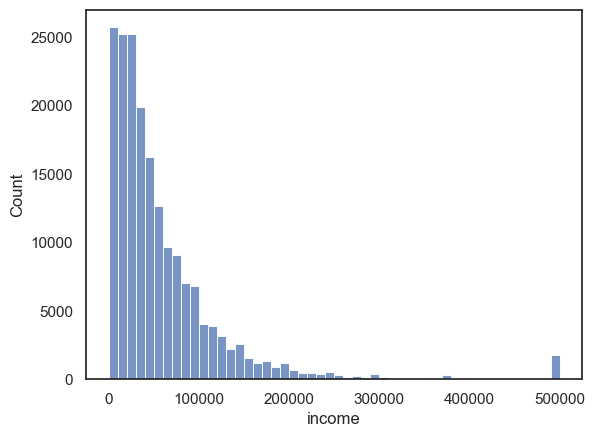

In [11]:
# TODO: plot the histogram of income (like in the lecture).
sns.histplot(df["income"],bins=50)

<Axes: xlabel='income', ylabel='Count'>

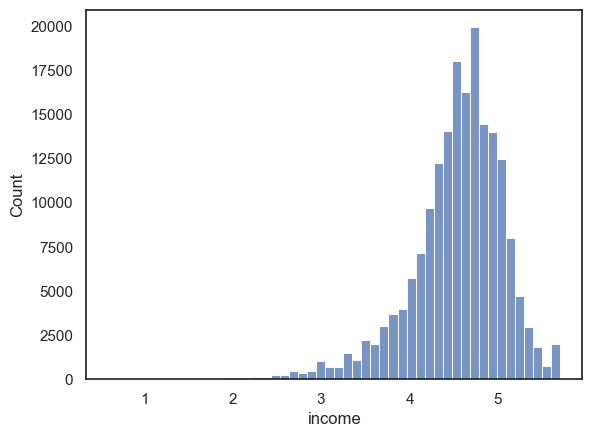

In [12]:
# TODO: plot the histogram of log10(income). Compare with the previous plot.
# Careful: log is not defined for zero or negative values. Filter if needed.
income_positive = df[df["income"] > 0]["income"]
sns.histplot(np.log10(income_positive),bins = 50)

**Question 4.** What does the log transformation reveal that the raw histogram hides?
le log plot nous permet de voir la distribution de l  income plus claire. Les haue valeur sont compresser ce qui permet de voir clairement la concentration et la variabilite de la plupart des income.

<Axes: xlabel='income'>

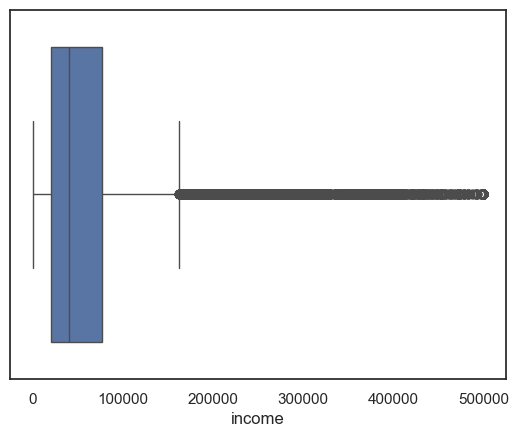

In [13]:
# TODO: plot the boxplot of income.
sns.boxplot(x=df["income"])

**Question 5.** The boxplot flags many points beyond the whiskers. Are they errors? Legitimate extreme values? Something else? You cannot tell from the plot alone, but what would help you decide?

ce sont des outliers des valeurs extremes de la distriution, des valeur qui sont plus haut que les autre. le plot montre que la majorite des gens ont leur income en essoud de 100000. On ne peux pas leur considere comme erreur seulment du boxplots.

## Part 3: Explore two more variables of your choice

Pick two other columns from the dataset. First, formulate some questions related to these variables (the abc slide). For each, produce whatever visualisation and summary statistics you find most informative. 

Suggestions to consider: `age`, `hours_per_week`, `sex`, `marital_status`, `education`, `worker_class`.

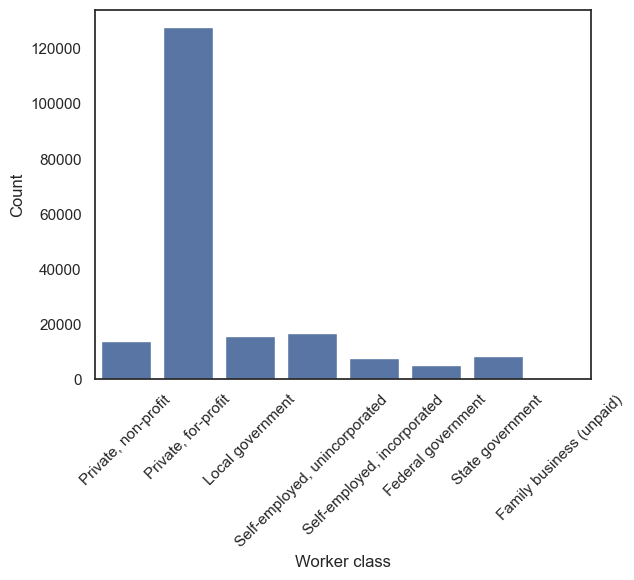

In [23]:
sns.countplot(data=df, x="worker_class")

plt.xlabel("Worker class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

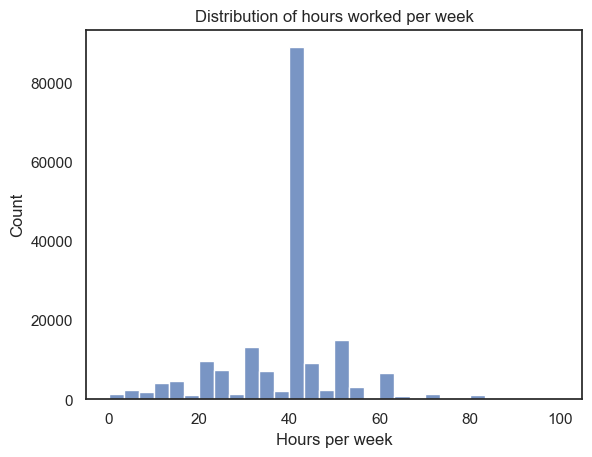

In [15]:
# TODO: variable 2
# Variable 2: hours_per_week

hours = df[df["hours_per_week"] >= 0]["hours_per_week"]

hours.describe()

sns.histplot(hours, bins=30)
plt.xlabel("Hours per week")
plt.ylabel("Count")
plt.title("Distribution of hours worked per week")
plt.show()

**Question 6.** Why did you choose these two? What did you learn about them?
j'ai choisis les deuxx variables suivantes: worker class et hours_per_week
pour pouvoir savoir la class des worker la plus presente dans le dataset et en meme temps le temps dans lequelle il travaillent le plus 
on peut remarquer que la classe private, for profit sont les plus presents et que l amajorite des worker travaillent 40 heures par semaine.

## Part 4: Feature engineering: binarise `income`

In many machine learning problems, `income` is used as a **binary target**: `high_income = 1` if a person earns above a threshold, `0` otherwise.

Create such a variable. But first: **what threshold?** There is no single right answer:

- A fixed value (e.g., \$50,000, as in the classic UCI Adult dataset)?
- The median (balanced classes by construction)?
- A quantile (Q75 for "high earners")?

Each choice implies a different definition of "high income".

In [29]:
# TODO: pick a threshold and create the binary variable 'high_income'.
threshold = df["income"].quantile(0.75)

df["high_income"] = np.nan

df.loc[df["income"] > threshold, "high_income"] = 1
df.loc[df["income"] <= threshold, "high_income"] = 0

In [30]:
# TODO: what is the class balance of your new variable?
print(df["high_income"].value_counts())
print(df["high_income"].value_counts(normalize=True)*100)

high_income
0.0    139938
1.0     46371
Name: count, dtype: int64
high_income
0.0    75.110703
1.0    24.889297
Name: proportion, dtype: float64


**Question 7.** Justify your choice of threshold. What downstream analysis does it support - or restrict?

le quantile 75% permet d'idenifier le 25% de personne ayant les revnus les plus eleve, c'es pour cela je l'ai choisis comme seuil.
En meme temps avec ce choix la division des classe n est pas tres equilibre du coup dans la classe 0 on peux avoir deux revenus qui sont completement different et donc une perte d'information.

In [31]:
df["worker_class"].value_counts(dropna=False)

worker_class
Private, for-profit              127654
Self-employed, unincorporated     16786
Local government                  15790
Private, non-profit               13811
State government                   8344
Self-employed, incorporated        7718
Federal government                 5077
Family business (unpaid)            564
Name: count, dtype: int64

## Part 5 -- Spot the anomalies

You have spent some time with this dataset. Look at it critically.

**Your task.** List **at least 3 anomalies, surprises, or things that look wrong** to you in this dataset. For each one, briefly explain what you observed and what you suspect might be going on.

There is no scoring today - but keep this list. You will come back to it in future sessions.

*Your notes here.*

1. hour_per_week continet des valeur negative
2. les done de sex sont mixed case 
3. valeur en dessus de 500k dans income sont capte comme si ils sont 500k 

---

**Before you leave.** Do *Restart & Run All*. Commit your notebook. See you next session.